# Word2Vec Model Training and Visualization

This notebook demonstrates how to:
1. Download and prepare the text8 dataset (if needed)
2. Train a Word2Vec model in a single cell and save it
3. Load the trained model from disk for subsequent exploration
4. Explore word relationships
5. Visualize the word embeddings using PCA and t-SNE

## 1. Import Required Libraries

In [1]:
import os
import gensim
import gensim.downloader as api
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


## 2. Helper Functions

#### Custom function to log the loss after each epoc

In [2]:
from gensim.models.callbacks import CallbackAny2Vec

class LossLogger(CallbackAny2Vec):
    """Callback to log loss after each epoch."""
    def __init__(self):
        self.epoch = 0
        self.losses = []
        self.previous_loss = 0.0

    def on_train_begin(self, model):
        """Called before training begins."""
        self.previous_loss = model.get_latest_training_loss()

    def on_epoch_begin(self, model):
        """Called at the beginning of each epoch."""
        self.epoch += 1

    def on_epoch_end(self, model):
        """Called at the end of each epoch."""
        current_loss = model.get_latest_training_loss()
        epoch_loss = current_loss - self.previous_loss
        self.losses.append(epoch_loss)
        self.previous_loss = current_loss
        print(f"Loss after epoch {self.epoch}: {epoch_loss:.2f}")


#### Download the text8 dataset and train the word2vec mode (CBOW)

In [3]:
def download_text8():
    """Download the text8 dataset using Gensim's API, if not found locally."""
    print("Downloading text8 dataset...")
    dataset = api.load('text8')
    with open('text8', 'w', encoding='utf-8') as f:
        for sentence in dataset:
            f.write(' '.join(sentence) + '\n')
    print("Download completed and saved to 'text8' file!")

def train_word2vec(epochs=10):
    """Train a Word2Vec model on the text8 dataset, with a progress callback and loss logger."""
    dataset_path = 'text8'
    if not os.path.exists(dataset_path):
        download_text8()

    # Callback classes
    class ProgressCallback:
        def __init__(self, total_epochs):
            self.total_epochs = total_epochs
            self.current_epoch = 0

        def on_train_begin(self, model):
            print("Training started!")

        def on_epoch_begin(self, model):
            self.current_epoch += 1
            print(f"Training epoch {self.current_epoch}/{self.total_epochs}")

        def on_epoch_end(self, model):
            print(f"Completed epoch {self.current_epoch}")

        def on_train_end(self, model):
            print("Training completed!")

    loss_logger = LossLogger()  # our custom loss-logging callback
    progress_logger = ProgressCallback(epochs)

    print("Loading sentences from text8 dataset...")
    sentences = LineSentence(dataset_path)

    print("Starting model training...")
    model = Word2Vec(
        sentences=sentences,
        sg=0,               # CBOW model; use sg=1 for skip-gram.
        vector_size=100,    # Dimension of the word vectors
        window=5,           # Context window size
        min_count=5,        # Ignore words with fewer occurrences
        workers=4,          # Number of CPU cores
        epochs=epochs,      # Number of training iterations
        compute_loss=True,  # Enable loss computation
        callbacks=[progress_logger, loss_logger]
    )

    return model, loss_logger  # Return both

## 3. **Train and Save** the Word2Vec Model (All in One Cell)

If you do not wish to retrain the model (and have a `word2vec.model` saved), you can skip this cell and simply run the **Load & Visualization** cell below.


Training the Word2Vec model...
Loading sentences from text8 dataset...
Starting model training...
Training started!
Training epoch 1/10
Completed epoch 1
Loss after epoch 1: 6436999.50
Training epoch 2/10
Completed epoch 2
Loss after epoch 2: 4744248.50
Training epoch 3/10
Completed epoch 3
Loss after epoch 3: 4379316.00
Training epoch 4/10
Completed epoch 4
Loss after epoch 4: 3804498.00
Training epoch 5/10
Completed epoch 5
Loss after epoch 5: 3530976.00
Training epoch 6/10
Completed epoch 6
Loss after epoch 6: 3487192.00
Training epoch 7/10
Completed epoch 7
Loss after epoch 7: 3407410.00
Training epoch 8/10
Completed epoch 8
Loss after epoch 8: 3353920.00
Training epoch 9/10
Completed epoch 9
Loss after epoch 9: 2017248.00
Training epoch 10/10
Completed epoch 10
Loss after epoch 10: 1737292.00
Training completed!

Model trained and saved as 'word2vec.model'!


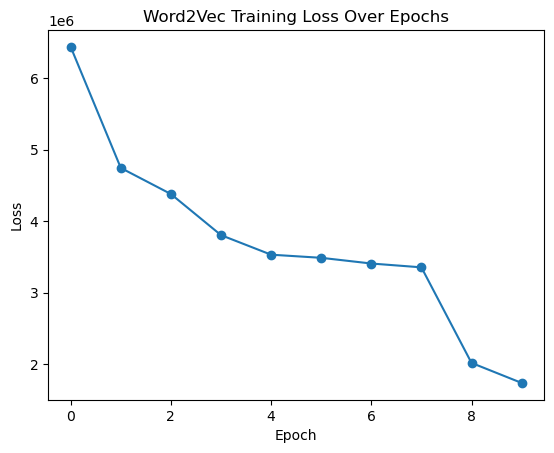

CPU times: total: 6min 48s
Wall time: 1min 50s


In [4]:
%%time
# Train Word2Vec in one cell and save it
try:
    print("\nTraining the Word2Vec model...")
    model, loss_logger = train_word2vec(epochs=10)  # e.g., 5 epochs
    model.save("word2vec.model")
    print("\nModel trained and saved as 'word2vec.model'!")
    
    # Plot the loss curve
    plt.plot(loss_logger.losses, marker='o')
    plt.title("Word2Vec Training Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()
    
except KeyboardInterrupt:
    print("Training was interrupted.")
except Exception as e:
    print(f"An error occurred during training: {str(e)}")

## 4. Load the Model and Perform Exploration + Visualization
You can run this cell *multiple times* with different parameters or different visualization methods without re-training.

If `word2vec.model` is already in your directory, this cell will just load it.

In [5]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.graph_objs as go

def explore_relationships(model):
    """
    Explore some relationships in the trained Word2Vec model.
    Prints most similar words, similarity scores, and analogies.
    """
    try:
        # Most similar to 'computer'
        print("\nMost similar to 'computer':")
        for word, sim in model.wv.most_similar('computer', topn=5):
            print(f"  {word}: {sim:.4f}")

        # Similarity between 'man' and 'woman'
        print("\nSimilarity between 'man' and 'woman':")
        print(f"  {model.wv.similarity('man', 'woman'):.4f}")

        # Existing analogy: king - man + woman
        print("\nAnalogy: king - man + woman = ?")
        for word, sim in model.wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=1):
            print(f"  {word}: {sim:.4f}")

        # Additional similar words
        print("\nMost similar to 'responsibility':")
        for word, sim in model.wv.most_similar('responsibility', topn=5):
            print(f"  {word}: {sim:.4f}")

        print("\nMost similar to 'community':")
        for word, sim in model.wv.most_similar('community', topn=5):
            print(f"  {word}: {sim:.4f}")

        print("\nMost similar to 'communism':")
        for word, sim in model.wv.most_similar('communism', topn=5):
            print(f"  {word}: {sim:.4f}")

        print("\nMost similar to 'plumber':")
        for word, sim in model.wv.most_similar('plumber', topn=5):
            print(f"  {word}: {sim:.4f}")

        # Additional analogy
        print("\nAnother analogy: paris - france + germany = ?")
        for word, sim in model.wv.most_similar(positive=['paris', 'germany'], negative=['france'], topn=1):
            print(f"  {word}: {sim:.4f}")

    except KeyError as e:
        print(f"Word not in vocabulary: {e}")


def visualize_embeddings_plotly(model, 
                                words=None, 
                                method='tsne', 
                                title='Word Embeddings Visualization'):
    """
    Visualize a subset of word embeddings in 2D using Plotly.

    :param model: Trained Word2Vec model.
    :param words: List of words to visualize (default set if None).
    :param method: Dimensionality reduction method: 'pca' or 'tsne'.
    :param title: Title for the plot.
    """
    if words is None:
        words = [
            'king', 'queen', 'man', 'woman', 'computer',
            'science', 'physics', 'dog', 'cat', 'car',
            'bike', 'paris', 'london', 'germany', 'france',
            'coffee', 'Poland', 'bitcoin', 'water',
            'christianity', 'islam', 'judaism',
            'love', 'hate', 'elephant', 'alabama'
        ]

    vectors = []
    labels = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
            labels.append(word)

    if not vectors:
        print("No vectors found for the requested words.")
        return

    vectors = np.array(vectors)

    # Choose PCA or t-SNE for dimensionality reduction (2D)
    if method == 'pca':
        reducer = PCA(n_components=2)
    else:
        reducer = TSNE(n_components=2, perplexity=5, random_state=42)

    reduced_vectors = reducer.fit_transform(vectors)
    
    # 2D coordinates
    x_vals = reduced_vectors[:, 0]
    y_vals = reduced_vectors[:, 1]

    # Plotly 2D scatter plot
    trace = go.Scatter(
        x=x_vals,
        y=y_vals,
        mode='markers+text',
        text=labels,
        textposition='top center'
    )
    layout = go.Layout(
        title=title + f' ({method.upper()}, 2D)',
        xaxis=dict(title='X'),
        yaxis=dict(title='Y')
    )
    fig = go.Figure(data=[trace], layout=layout)
    fig.show()

# Main logic for loading the model, exploring relationships, and visualizing embeddings
try:
    print("\nLoading the Word2Vec model from 'word2vec.model'...")
    loaded_model = Word2Vec.load('word2vec.model')
    print("Model loaded successfully!")

    # Explore relationships
    explore_relationships(loaded_model)

    # Visualize embeddings with PCA in 2D
    print("\nVisualizing with PCA in 2D (Plotly)...")
    visualize_embeddings_plotly(
        loaded_model,
        method='pca',
        title='Word Embeddings (PCA, 2D)'
    )

    # Visualize embeddings with t-SNE in 2D
    print("\nVisualizing with t-SNE in 2D (Plotly)...")
    visualize_embeddings_plotly(
        loaded_model,
        method='tsne',
        title='Word Embeddings (t-SNE, 2D)'
    )

except FileNotFoundError:
    print("'word2vec.model' not found. Please make sure the file is in this directory or train and save a model first.")
except Exception as e:
    print(f"An error occurred: {str(e)}")



Loading the Word2Vec model from 'word2vec.model'...
Model loaded successfully!

Most similar to 'computer':
  computers: 0.7131
  computing: 0.6948
  console: 0.6403
  hardware: 0.6324
  mainframe: 0.6316

Similarity between 'man' and 'woman':
  0.6962

Analogy: king - man + woman = ?
  queen: 0.6491

Most similar to 'responsibility':
  obligation: 0.6636
  responsibilities: 0.6577
  authority: 0.6524
  privilege: 0.6396
  legitimacy: 0.6275

Most similar to 'community':
  communities: 0.6736
  organisation: 0.6562
  organization: 0.6548
  organizations: 0.5980
  society: 0.5798

Most similar to 'communism':
  socialism: 0.8029
  fascism: 0.8028
  marxism: 0.7885
  totalitarianism: 0.7726
  capitalism: 0.7623

Most similar to 'plumber':
Word not in vocabulary: "Key 'plumber' not present in vocabulary"

Visualizing with PCA in 2D (Plotly)...



Visualizing with t-SNE in 2D (Plotly)...


#### Similarity Matrix Heatmap for Historical Figures

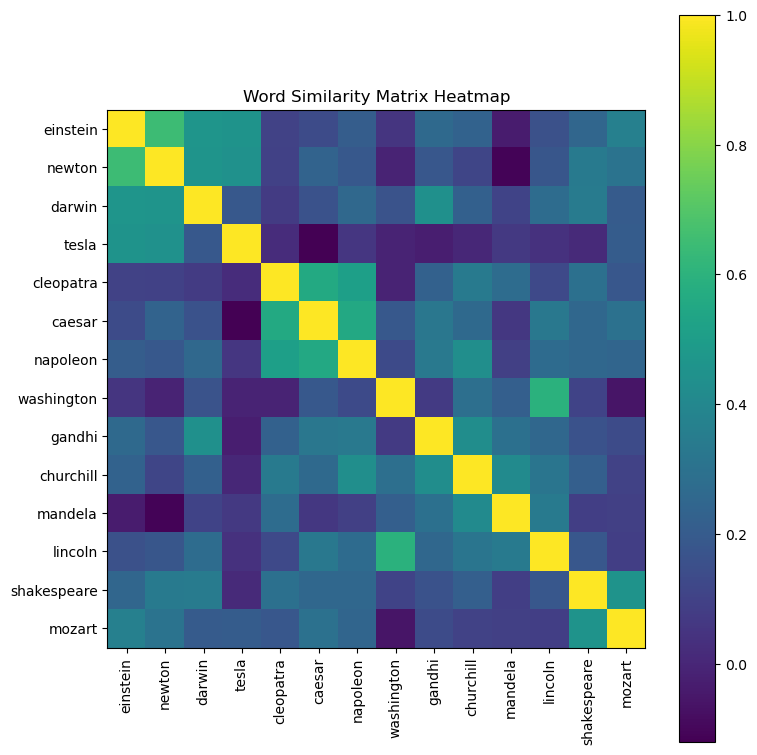

In [6]:
def similarity_heatmap(model, words=None):
    """
    Compute and visualize a similarity matrix (word x word).
    """
    if words is None:
        words = [
            'einstein', 'newton', 'darwin', 'tesla', 'cleopatra', 
            'caesar', 'napoleon', 'washington', 'gandhi', 'churchill', 
            'mandela', 'lincoln', 'shakespeare', 'mozart', 'da_vinci'
        ]

    valid_words = [w for w in words if w in model.wv]
    n = len(valid_words)

    # Build pairwise similarity matrix
    similarity_matrix = np.zeros((n, n))
    for i, w1 in enumerate(valid_words):
        for j, w2 in enumerate(valid_words):
            similarity_matrix[i, j] = model.wv.similarity(w1, w2)

    # Plot the similarity matrix
    plt.figure(figsize=(8, 8))
    plt.imshow(similarity_matrix, interpolation='nearest')
    plt.colorbar()
    plt.xticks(range(n), valid_words, rotation=90)
    plt.yticks(range(n), valid_words)
    plt.title("Word Similarity Matrix Heatmap")
    plt.tight_layout()
    plt.show()
similarity_heatmap(loaded_model)
